<a href="https://colab.research.google.com/github/sonamaryanish/Regression/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
"""
Dataset
Use the Iris dataset available in the sklearn library.
Key components to be fulfilled :
Loading and Preprocessing (1 mark)
● Load the Iris dataset from sklearn.
● Drop the species column since this is a clustering problem.
"""

import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

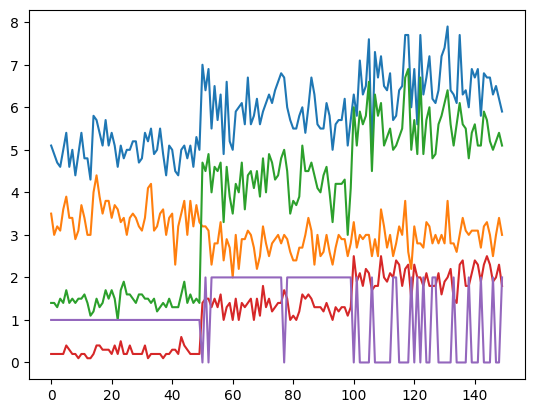

In [23]:
df.shape
plt.plot(df)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [11]:

# Add species column (target) just to demonstrate dropping it
df['species'] = iris.target

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
# Drop the species column for clustering
df_clustering = df.drop(columns=['species'])

In [16]:
# View the result
print(df_clustering.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


Description of KMeans Clustering

K-Means Clustering is an unsupervised learning algorithm that groups data into K clusters based on similarity.

How it works


      Choose the number of clusters K.

      Randomly initialize K centroids.

      Assign each data point to the nearest centroid.

      Recalculate centroids as the mean of assigned points.

      Repeat steps 3–4 until cluster assignments stop changing.





Why KMeans is suitable for the Iris dataset

KMeans works well for the Iris dataset because:

      The dataset contains 3 natural groups of flowers.

      The features (sepal and petal measurements) are numerical and continuous.

      The dataset is small and well-structured, making clustering efficient.

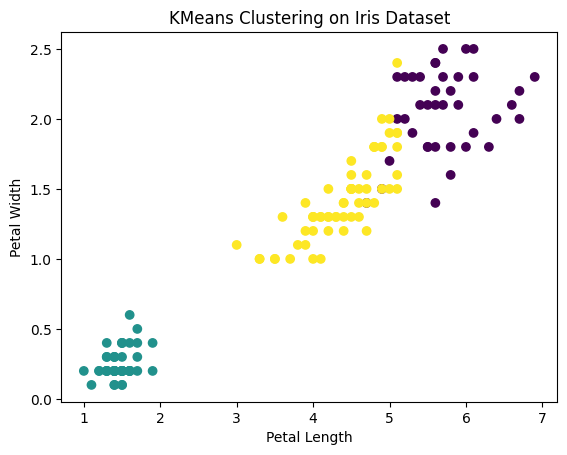

In [33]:
# Apply KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(df)
df['cluster'] = kmeans.fit_predict(df)

# Visualize clusters (Petal Length vs Petal Width)
plt.scatter(df['petal length (cm)'], df['petal width (cm)'],
            c=df['cluster'], cmap='viridis')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KMeans Clustering on Iris Dataset")
plt.show()

Description of Hierarchical Clustering

Hierarchical Clustering builds a hierarchy of clusters represented as a tree structure called a dendrogram.

How it works

      Start with each data point as its own cluster.

      Compute distances between clusters.

      Merge the two closest clusters.

      Repeat until all points are merged into one cluster.

This method does not require specifying the number of clusters beforehand.



Why Hierarchical Clustering is suitable for the Iris dataset

Hierarchical clustering works well because:

      The dataset is small (150 samples), which suits hierarchical methods.

      It helps visualize relationships between clusters using a dendrogram.

      It can reveal natural grouping structures in the flower measurements

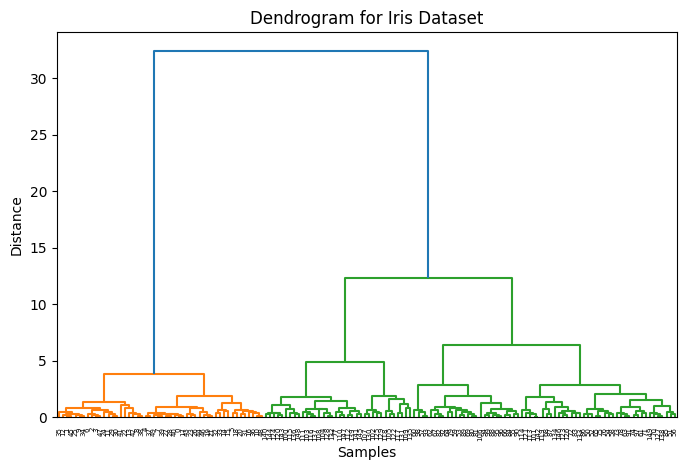

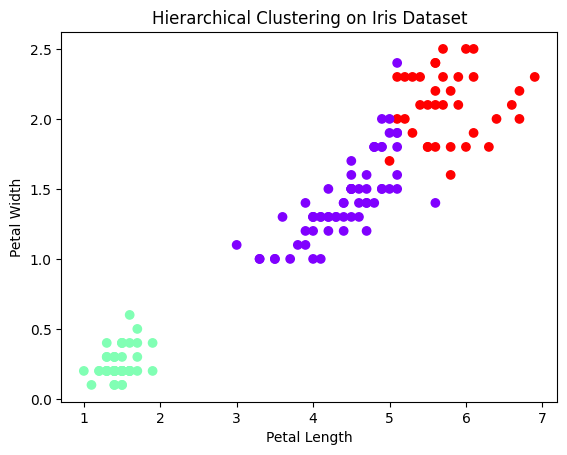

In [36]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Dendrogram
plt.figure(figsize=(8,5))
dendrogram = sch.dendrogram(sch.linkage(df.iloc[:,0:4], method='ward'))
plt.title("Dendrogram for Iris Dataset")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# Apply Hierarchical clustering
hc = AgglomerativeClustering(n_clusters=3)
df['hc_cluster'] = hc.fit_predict(df.iloc[:,0:4])

# Visualization
plt.scatter(df['petal length (cm)'], df['petal width (cm)'],
            c=df['hc_cluster'], cmap='rainbow')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Hierarchical Clustering on Iris Dataset")
plt.show()
